# Crypto Funding Premium: Causal DML Estimation

Does the basis premium have a direct effect on future perpetual-futures returns after
accounting for observed market conditions? This notebook applies double machine learning
(DML) to the 14-day premium z-score at the 8-hour funding cadence.

**Learning objectives**

- Separate predictive association from a causally interpretable treatment effect
- Apply cross-fitting and embargoes to complete timestamp panels
- Evaluate uncertainty with panel HAC inference and a symbolwise block placebo

**Book reference**: Chapter 15, Section 15.6 (Cross-Dataset Causal Evidence)

**Prerequisites**: [`02_labels`](02_labels.ipynb) and
[`03_financial_features`](03_financial_features.ipynb)

## Identification and validation contract

DML can identify a causal effect only if the selected confounders block all relevant backdoor
paths, treatment variation overlaps across confounder states, and one contract's treatment does
not affect another contract's outcome. Those assumptions are not proven by a small p-value.
SUTVA is particularly fragile in crypto because common liquidity and market-wide flows connect
assets.

The fixed 19-contract list admits assets only after listing, but it was selected with later
survival information rather than a point-in-time liquidity rule. The estimate is therefore
conditional on this research panel and does not identify an effect for the historical perp market.

The operational contract is testable: estimation stops before the sealed holdout, each fold uses
complete timestamps, the embargo spans three 8-hour timestamps, and no nuisance model sees its
evaluation timestamps. The placebo permutes three-timestamp blocks separately within each symbol.

In [1]:
"""Panel-time causal DML with a read-only frozen-result path."""

import json
import sqlite3
import time
import warnings
from datetime import UTC, datetime, timedelta

import numpy as np
import plotly.graph_objects as go
import polars as pl
import statsmodels.api as sm
import yaml
from sklearn.ensemble import HistGradientBoostingRegressor

from case_studies.utils.causal import classify_refutation, embargo_from_buffer
from case_studies.utils.registry import modeling_input_fingerprint
from case_studies.utils.registry.registration import (
    register_causal_run as register_causal_record,
)
from case_studies.utils.registry.specs import (
    build_training_spec,
    canonical_json,
    training_hash_from_spec,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings(
    "ignore",
    message="'Y' is deprecated and will be removed in a future version, please use 'YE' instead.",
    category=FutureWarning,
    module="ml4t.diagnostic.splitters.calendar",
)

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
RANDOM_SEED = 42
CV_FOLDS = 5
MAX_SAMPLES = 50000
N_PLACEBO = 100
FORCE_RETRAIN = False
ESTIMATOR_CONTRACT = "panel_time_v3"

In [3]:
set_global_seeds(RANDOM_SEED)
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
PRIMARY_LABEL = PRIMARY_LABEL or setup["labels"]["primary"]

dml_cfg = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "causal_dml")[0]

causal_cfg = setup["causal"]
TREATMENT_COL = causal_cfg["treatment"]
CONFOUNDER_COLS = list(causal_cfg["confounders"])
HOLDOUT_START = setup["evaluation"]["holdout_start"]
HOLDOUT_CUTOFF = datetime.fromisoformat(HOLDOUT_START).replace(tzinfo=UTC)
LABEL_HORIZON = timedelta(hours=8)

print(f"DML config: {dml_cfg['config_name']}")
print(f"Treatment: {TREATMENT_COL} | outcome: {PRIMARY_LABEL}")
print(f"Confounders: {CONFOUNDER_COLS}")

DML config: dml
Treatment: premium_zscore_14d | outcome: fwd_ret_8h
Confounders: ['price_vol_14d', 'funding_rate', 'premium_dev_mean_14d']


## Load the modeling frame

The shared loader joins the financial, temporal, and label artifacts. The analysis below keeps
Polars through filtering and validation; NumPy is used only at the model boundary.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
dataset = mds.dataset
label_col = mds.label_col
date_col = mds.date_col
entity_cols = mds.entity_cols
symbol_col = entity_cols[0]
assert mds.label_buffer.upper() == "8H"
INPUT_FINGERPRINT = modeling_input_fingerprint(
    CASE_DIR,
    PRIMARY_LABEL,
    mds.splits,
    mds.feature_names,
    MAX_SYMBOLS,
)

analysis_cols = list(
    dict.fromkeys([date_col, symbol_col, TREATMENT_COL, label_col, *CONFOUNDER_COLS])
)
missing = sorted(set(analysis_cols) - set(dataset.columns))
if missing:
    raise ValueError(f"Missing analysis columns: {missing}")

EMBARGO_PERIODS = embargo_from_buffer(mds.label_buffer)
BLOCK_SIZE = EMBARGO_PERIODS
print(f"Joined frame: {dataset.height:,} rows x {dataset.width} columns")
print(f"Label buffer: {mds.label_buffer} | embargo: {EMBARGO_PERIODS} timestamps")
print(f"Input lineage: {INPUT_FINGERPRINT[:12]}")

Joined frame: 100,741 rows x 47 columns
Label buffer: 8H | embargo: 3 timestamps
Input lineage: 962cfd4e882e


## Seal the holdout and retain whole timestamp panels

The sample cap selects the most recent complete timestamps before 2024-01-01. It never cuts a
timestamp cross-section, so a time code always represents one complete decision panel.

In [5]:
def _whole_timestamp_tail(frame: pl.DataFrame, timestamp: str, max_rows: int) -> pl.DataFrame:
    """Return the most recent complete timestamp panels within a row budget."""
    if max_rows <= 0 or frame.height <= max_rows:
        return frame.sort([timestamp, symbol_col])
    counts = frame.group_by(timestamp).len().sort(timestamp)
    counts = counts.with_columns(pl.col("len").reverse().cum_sum().reverse().alias("suffix_n"))
    keep = counts.filter(pl.col("suffix_n") <= max_rows).select(timestamp)
    if keep.is_empty():
        raise ValueError("MAX_SAMPLES is smaller than the final timestamp panel")
    return frame.join(keep, on=timestamp, how="semi").sort([timestamp, symbol_col])

In [6]:
def _prepare_analysis(
    frame: pl.DataFrame,
    columns: list[str],
    timestamp: str,
    holdout_cutoff: datetime,
    label_horizon: timedelta,
    max_rows: int,
) -> pl.DataFrame:
    """Seal label endpoints, remove incomplete rows, and cap by whole timestamp."""
    pre_holdout = (
        frame.select(columns)
        .drop_nulls()
        .filter(pl.col(timestamp) < pl.lit(holdout_cutoff - label_horizon))
        .sort([timestamp, symbol_col])
    )
    return _whole_timestamp_tail(pre_holdout, timestamp, max_rows)

In [7]:
analysis = _prepare_analysis(
    dataset,
    analysis_cols,
    date_col,
    HOLDOUT_CUTOFF,
    LABEL_HORIZON,
    MAX_SAMPLES,
)

if analysis.get_column(date_col).max() + LABEL_HORIZON >= HOLDOUT_CUTOFF:
    raise AssertionError("A DML label endpoint reaches the sealed holdout")

panel_sizes = analysis.group_by(date_col).len()
print(f"Analysis frame: {analysis.height:,} rows, {analysis[date_col].n_unique():,} timestamps")
print(f"Date range: {analysis[date_col].min()} to {analysis[date_col].max()}")
print(f"Panel size: {panel_sizes['len'].min()}-{panel_sizes['len'].max()} symbols")

Analysis frame: 50,000 rows, 3,095 timestamps
Date range: 2021-01-06 16:00:00+00:00 to 2023-12-31 08:00:00+00:00
Panel size: 5-19 symbols


## Cross-fit nuisance models by timestamp

Each expanding fold trains on earlier timestamp codes and predicts a later block. Three complete
timestamps separate the train and test blocks. The function returns fold assignments so the split
contract remains directly inspectable.

In [8]:
def _crossfit_panel_residuals(
    outcome: np.ndarray,
    treatment: np.ndarray,
    confounders: np.ndarray,
    time_codes: np.ndarray,
    n_folds: int,
    embargo: int,
    seed: int,
    outcome_residuals: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Cross-fit nuisance models using expanding complete-timestamp folds."""
    y_res = np.full(outcome.size, np.nan) if outcome_residuals is None else outcome_residuals.copy()
    t_res = np.full(outcome.size, np.nan)
    fold_id = np.full(outcome.size, -1, dtype=int)
    n_times = int(time_codes.max()) + 1
    fold_size = n_times // (n_folds + 1)
    for fold in range(n_folds):
        train_end = (fold + 1) * fold_size
        test_start = train_end + embargo
        test_end = min(test_start + fold_size, n_times)
        train = time_codes < train_end
        test = (time_codes >= test_start) & (time_codes < test_end)
        if train.sum() < 50 or test.sum() < 10:
            continue
        model_t = HistGradientBoostingRegressor(max_iter=50, max_depth=3, random_state=seed)
        model_t.fit(confounders[train], treatment[train])
        if outcome_residuals is None:
            model_y = HistGradientBoostingRegressor(max_iter=50, max_depth=3, random_state=seed)
            model_y.fit(confounders[train], outcome[train])
            y_res[test] = outcome[test] - model_y.predict(confounders[test])
        t_res[test] = treatment[test] - model_t.predict(confounders[test])
        fold_id[test] = fold
    return y_res, t_res, fold_id

## Estimate the residual-on-residual effect

The final regression includes an intercept and uses Driscoll-Kraay panel HAC covariance by
timestamp. Its bandwidth is the larger of the three-period embargo and the cube-root rule applied
to the number of evaluated timestamps.

In [9]:
def _panel_effect(
    y_res: np.ndarray, t_res: np.ndarray, time_codes: np.ndarray, embargo: int
) -> dict[str, float | int]:
    """Estimate the DML effect with panel HAC uncertainty."""
    valid = np.isfinite(y_res) & np.isfinite(t_res)
    y_valid, t_valid = y_res[valid], t_res[valid]
    valid_time = time_codes[valid]
    n_times = np.unique(valid_time).size
    hac_lags = max(embargo, int(n_times ** (1 / 3)))
    iid = sm.OLS(y_valid, sm.add_constant(t_valid)).fit()
    robust = iid.get_robustcov_results(
        cov_type="hac-groupsum",
        time=valid_time - valid_time.min(),
        maxlags=hac_lags,
        use_correction="hac",
        df_correction=False,
    )
    return {
        "theta": float(iid.params[1]),
        "se_iid": float(iid.bse[1]),
        "se_hac": float(robust.bse[1]),
        "t_stat_hac": float(robust.tvalues[1]),
        "p_value_hac": float(robust.pvalues[1]),
        "n_obs": int(valid.sum()),
        "n_timestamps": int(n_times),
        "hac_maxlags": int(hac_lags),
    }

## Build a symbolwise block placebo

Each symbol's treatment history is divided into consecutive three-timestamp blocks. Only block
order changes, which preserves values and within-block ordering without mixing observations across
symbols.

In [10]:
def _block_permute_by_symbol(
    treatment: np.ndarray,
    symbols: np.ndarray,
    time_codes: np.ndarray,
    block_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Permute treatment blocks separately within each symbol."""
    permuted = treatment.copy()
    for symbol in np.unique(symbols):
        idx = np.flatnonzero(symbols == symbol)
        idx = idx[np.argsort(time_codes[idx], kind="stable")]
        n_full = idx.size // block_size
        blocks = [idx[start * block_size : (start + 1) * block_size] for start in range(n_full)]
        source_blocks = [blocks[i] for i in rng.permutation(n_full)]
        if n_full * block_size < idx.size:
            source_blocks.append(idx[n_full * block_size :])
        source = np.concatenate(source_blocks)
        permuted[idx] = treatment[source]
    return permuted

## Run the corrected panel-time DML

The empirical placebo p-value uses the plus-one correction, so a finite placebo sample can never
report impossible zero probability.

In [11]:
def _placebo_refutation(
    outcome: np.ndarray,
    treatment: np.ndarray,
    confounders: np.ndarray,
    symbols: np.ndarray,
    time_codes: np.ndarray,
    observed_effect: float,
) -> dict:
    rng = np.random.default_rng(RANDOM_SEED)
    placebo_y, _, _ = _crossfit_panel_residuals(
        outcome,
        treatment,
        confounders,
        time_codes,
        min(3, CV_FOLDS),
        EMBARGO_PERIODS,
        RANDOM_SEED,
    )
    effects = []
    for _ in range(N_PLACEBO):
        permuted = _block_permute_by_symbol(treatment, symbols, time_codes, BLOCK_SIZE, rng)
        py, pt, _ = _crossfit_panel_residuals(
            outcome,
            permuted,
            confounders,
            time_codes,
            min(3, CV_FOLDS),
            EMBARGO_PERIODS,
            RANDOM_SEED,
            placebo_y,
        )
        effects.append(_panel_effect(py, pt, time_codes, EMBARGO_PERIODS)["theta"])
    effect_array = np.asarray(effects)
    empirical_p = (1 + np.sum(np.abs(effect_array) >= abs(observed_effect))) / (len(effects) + 1)
    return {
        "empirical_p": float(empirical_p),
        "placebo_effects": effects,
        "n_successful": len(effects),
        "refutation_class": classify_refutation(float(empirical_p)),
    }

In [12]:
def _run_panel_dml(frame: pl.DataFrame) -> dict:
    """Run aligned OLS, corrected panel DML, and the block placebo."""
    started_at = datetime.now(UTC).isoformat()
    started = time.perf_counter()
    treatment = frame[TREATMENT_COL].to_numpy()
    outcome = frame[label_col].to_numpy()
    confounders = frame.select(CONFOUNDER_COLS).to_numpy()
    symbols = frame[symbol_col].to_numpy()
    time_codes = frame[date_col].rank("dense").to_numpy().astype(int) - 1
    y_res, t_res, fold_id = _crossfit_panel_residuals(
        outcome, treatment, confounders, time_codes, CV_FOLDS, EMBARGO_PERIODS, RANDOM_SEED
    )
    dml = _panel_effect(y_res, t_res, time_codes, EMBARGO_PERIODS)
    evaluated = np.isfinite(y_res) & np.isfinite(t_res)
    naive = float(
        np.linalg.lstsq(sm.add_constant(treatment[evaluated]), outcome[evaluated], rcond=None)[0][1]
    )
    refutation = _placebo_refutation(
        outcome, treatment, confounders, symbols, time_codes, dml["theta"]
    )
    adjustment_gap = naive - dml["theta"]
    dml.update({"Y_res": y_res, "T_res": t_res, "fold_id": fold_id})
    return {
        "naive_effect": naive,
        "dml_result": dml,
        "adjustment_gap": adjustment_gap,
        "adjustment_gap_pct": adjustment_gap / abs(dml["theta"]) * 100,
        "refutation": refutation,
        "p_value_hac": dml["p_value_hac"],
        "hac_maxlags": dml["hac_maxlags"],
        "n_obs": frame.height,
        "started_at": started_at,
        "elapsed_s": time.perf_counter() - started,
    }

## Reuse frozen registry provenance without retraining

The production registry is read-only during publication sign-off. If its matching row exists, the
notebook displays it as a historical result from the superseded row-based method. An empty isolated
registry instead exercises the corrected estimator and registers only inside that isolated root.

In [13]:
def _registry_result_from_row(row: dict, estimator_contract: str) -> dict:
    """Convert one registry row to the notebook result contract."""
    dml = {
        "theta": row["dml_effect"],
        "se_iid": float("nan"),
        "se_hac": row["dml_se_hac"],
        "t_stat_hac": row["dml_effect"] / row["dml_se_hac"],
        "p_value_hac": row["p_value_hac"],
        "n_obs": row["n_obs"],
        "hac_maxlags": 0,
    }
    refutation_p = row["refutation_p"]
    corrected = estimator_contract == ESTIMATOR_CONTRACT
    return {
        "naive_effect": row["naive_effect"] if corrected else None,
        "dml_result": dml,
        "adjustment_gap_pct": row["confounding_bias_pct"] if corrected else None,
        "refutation": {
            "empirical_p": refutation_p,
            "refutation_class": classify_refutation(refutation_p),
        },
        "p_value_hac": row["p_value_hac"],
        "hac_maxlags": 0,
        "n_obs": row["n_obs"],
        "causal_hash": row["causal_hash"],
        "estimator_contract": estimator_contract,
    }

In [14]:
def _panel_spec() -> dict:
    """Build the versioned identity for the corrected estimator."""
    return build_training_spec(
        "causal_dml",
        "dml",
        PRIMARY_LABEL,
        n_folds=CV_FOLDS,
        seed=RANDOM_SEED,
        causal_params={
            "treatment": TREATMENT_COL,
            "embargo": EMBARGO_PERIODS,
            "confounders": CONFOUNDER_COLS,
            "estimator_contract": ESTIMATOR_CONTRACT,
            "holdout_start": HOLDOUT_START,
            "input_fingerprint": INPUT_FINGERPRINT,
            "label_horizon_hours": int(LABEL_HORIZON.total_seconds() // 3600),
            "max_samples": MAX_SAMPLES,
            "max_symbols": MAX_SYMBOLS,
            "n_placebo": N_PLACEBO,
        },
    )

In [15]:
def _panel_causal_hash() -> str:
    return training_hash_from_spec(_panel_spec())

In [16]:
def _load_registry_result(registry_path) -> tuple[dict | None, str | None]:
    """Load a versioned corrected row or the separately identified legacy row."""
    if FORCE_RETRAIN or not registry_path.exists():
        return None, None
    uri = f"file:{registry_path}?mode=ro"
    corrected_query = "SELECT * FROM causal_runs WHERE causal_hash = ? LIMIT 1"
    legacy_query = """
        SELECT * FROM causal_runs
        WHERE label = ? AND treatment = ? AND n_folds = ? AND embargo = ? AND notebook = ?
          AND causal_hash != ?
          AND (spec_json IS NULL OR spec_json NOT LIKE '%"estimator_contract"%')
        ORDER BY created_at DESC LIMIT 1
    """
    with sqlite3.connect(uri, uri=True) as connection:
        corrected = pl.read_database(
            corrected_query,
            connection,
            execute_options={"parameters": (_panel_causal_hash(),)},
        )
        if not corrected.is_empty():
            return (
                _registry_result_from_row(corrected.row(0, named=True), ESTIMATOR_CONTRACT),
                ESTIMATOR_CONTRACT,
            )
        legacy = pl.read_database(
            legacy_query,
            connection,
            execute_options={
                "parameters": (
                    PRIMARY_LABEL,
                    TREATMENT_COL,
                    CV_FOLDS,
                    EMBARGO_PERIODS,
                    "11_causal_dml",
                    _panel_causal_hash(),
                )
            },
        )
    if legacy.is_empty():
        return None, None
    return _registry_result_from_row(legacy.row(0, named=True), "row_panel_v1"), "row_panel_v1"

In [17]:
def _register_panel_result(results: dict) -> str:
    """Persist the corrected result under its versioned estimator identity."""
    spec = _panel_spec()
    causal_hash = training_hash_from_spec(spec)
    dml_result = results["dml_result"]
    refutation = results["refutation"]
    register_causal_record(
        CASE_STUDY_ID,
        causal_hash,
        label=PRIMARY_LABEL,
        treatment=TREATMENT_COL,
        confounders_json=json.dumps(CONFOUNDER_COLS),
        embargo=EMBARGO_PERIODS,
        n_folds=CV_FOLDS,
        n_obs=int(dml_result["n_obs"]),
        dml_effect=float(dml_result["theta"]),
        dml_se_hac=float(dml_result["se_hac"]),
        p_value_hac=float(results["p_value_hac"]),
        naive_effect=float(results["naive_effect"]),
        confounding_bias_pct=float(results["adjustment_gap_pct"]),
        refutation_p=float(refutation["empirical_p"]),
        spec_json=canonical_json(spec),
        notebook="11_causal_dml",
        started_at=results.get("started_at"),
        elapsed_s=results.get("elapsed_s"),
        case_dir=CASE_DIR,
    )
    return causal_hash

In [18]:
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
results, ESTIMATOR_SOURCE = _load_registry_result(REGISTRY_PATH)
RESULT_MODE = (
    "frozen registered summary (superseded methodology)"
    if ESTIMATOR_SOURCE == "row_panel_v1"
    else "corrected panel-time estimate"
)
SE_LABEL = "stored HAC" if ESTIMATOR_SOURCE == "row_panel_v1" else "panel HAC"
CACHE_STATUS = "cached" if results is not None else "fresh"

if results is None:
    results = _run_panel_dml(analysis)
    results["causal_hash"] = _register_panel_result(results)
    results["estimator_contract"] = ESTIMATOR_CONTRACT

dml = results["dml_result"]
refutation = results["refutation"]
print(f"Result mode: {RESULT_MODE}")
print(f"Result source: {CACHE_STATUS}")
print(f"DML effect: {dml['theta']:+.8f} | {SE_LABEL} SE: {dml['se_hac']:.8f}")
print(f"HAC p-value: {results['p_value_hac']:.4f}")
print(f"Placebo: {refutation['refutation_class']} (p={refutation['empirical_p']:.4f})")

Result mode: corrected panel-time estimate
Result source: cached
DML effect: -0.00087378 | panel HAC SE: 0.00092020
HAC p-value: 0.3423
Placebo: Passes (p=0.0099)


## Effect estimate and uncertainty

A corrected run compares the unadjusted association and DML estimate on the exact same cross-fit
evaluation rows. The historical frozen row omits that comparison because its stored unadjusted
coefficient used a different sample. The interval is panel HAC for the corrected estimator and
the stored historical HAC interval for the frozen row.

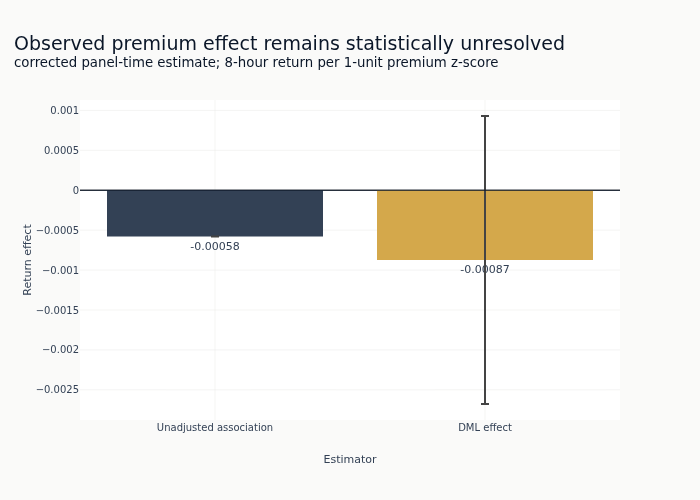

In [19]:
if results["naive_effect"] is None:
    estimator_labels = ["Stored DML effect"]
    effects = [dml["theta"]]
    errors = [1.96 * dml["se_hac"]]
    colors = [COLORS["amber"]]
else:
    estimator_labels = ["Unadjusted association", "DML effect"]
    effects = [results["naive_effect"], dml["theta"]]
    errors = [0.0, 1.96 * dml["se_hac"]]
    colors = [COLORS["neutral"], COLORS["amber"]]
fig = go.Figure(
    go.Bar(
        x=estimator_labels,
        y=effects,
        error_y={"type": "data", "array": errors, "visible": True},
        marker_color=colors,
        text=[f"{value:+.5f}" for value in effects],
        textposition="outside",
    )
)
fig.add_hline(y=0, line_color=COLORS["blue"], line_width=1)
fig.update_layout(
    title={
        "text": "Observed premium effect remains statistically unresolved"
        f"<br><sup>{RESULT_MODE}; 8-hour return per 1-unit premium z-score</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Estimator",
    yaxis_title="Return effect",
    showlegend=False,
)
fig.show()

## Interpretation

The frozen registry row is retained for provenance, but it is not current causal evidence. Its
row-indexed folds admitted holdout observations and could divide a timestamp panel between train
and test. Its stored unadjusted coefficient also used a different row set and is therefore omitted
from the chart. Its p-values do not support the direct-channel claim printed by the older notebook.

A fresh isolated run uses only pre-holdout observations and complete timestamp folds. Even then,
DML addresses observed confounding rather than proving conditional ignorability, overlap, or
SUTVA. The premium remains a predictive candidate, while causal language depends on the corrected
estimate and its panel-aware uncertainty.

## Key takeaways

1. The sealed 2024-2025 holdout is excluded before estimation and sample capping.
2. Cross-fitting and embargoes operate on complete 8-hour timestamps, not panel rows.
3. The frozen row documents prior output but cannot establish a causal channel under its
   superseded validation method.
4. A corrected result remains conditional on strong, unverified identification assumptions,
   especially limited cross-asset interference.

**Next**: [`12_model_analysis`](12_model_analysis.ipynb) compares model families and prepares the
case-study synthesis.

In [20]:
summary = {
    "mode": RESULT_MODE,
    "analysis_rows": analysis.height,
    "analysis_timestamps": analysis[date_col].n_unique(),
    "analysis_end": str(analysis[date_col].max()),
    "dml_effect": float(dml["theta"]),
    "dml_se_hac": float(dml["se_hac"]),
    "p_value_hac": float(results["p_value_hac"]),
    "refutation_p_value": float(refutation["empirical_p"]),
}
if results["naive_effect"] is not None:
    summary["unadjusted_effect_evaluation_rows"] = float(results["naive_effect"])
    summary["adjustment_gap_pct"] = float(results["adjustment_gap_pct"])
print("\nCausal DML summary")
for key, value in summary.items():
    print(f"  {key}: {value}")
print(f"\n[OK] Causal DML analysis complete for {CASE_STUDY_ID}")


Causal DML summary
  mode: corrected panel-time estimate
  analysis_rows: 50000
  analysis_timestamps: 3095
  analysis_end: 2023-12-31 08:00:00+00:00
  dml_effect: -0.0008737778571018406
  dml_se_hac: 0.0009201996650434496
  p_value_hac: 0.3423452100336962
  refutation_p_value: 0.009900990099009901
  unadjusted_effect_evaluation_rows: -0.0005805683676422752
  adjustment_gap_pct: 33.55652550318533

[OK] Causal DML analysis complete for crypto_perps_funding
